# Jacobian normalization for nonhomogeneous ODEs: $\frac{dy}{dx} = -Cy^2$

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.optim.lr_scheduler import ExponentialLR
import numpy as np
import matplotlib.pyplot as plt

from pinn import PINN

In [2]:
def plotting(C, preds, x_coloc):

    x_coloc = x_coloc.detach().numpy()
    
    plt.figure(figsize=(10,8))
    plt.plot(x_coloc, preds, 'r', label='PINN')
    plt.plot(x_coloc, 1.0 / (1.0 + C * x_coloc), color='green', linestyle=':', label='Exact solution')
    plt.xlabel(r'$x$') 
    plt.ylabel(r'$y$') 
    plt.xscale('log')
    plt.legend()
    plt.show()

## PINN parameters

In [3]:
# Parameters of this problem:
normalize_jacobian = True
C_test = np.logspace(0, 4, 20, endpoint=True)
early_stopping_loss = 1e-8

n_epochs = 500_000
num_coloc = 1000
lr = 8.0e-5
x_co = np.exp(np.linspace(-15.0, 0.0, num_coloc))
x_co = torch.tensor(x_co, dtype=torch.float32).view(-1, 1).requires_grad_(True)

## Loss function

In [4]:
def make_loss(C, normalize_jac):
    def pinn_loss(self, x):
            
        x = x.clone().detach().requires_grad_(True)

        # Forward pass
        y = self.forward(x)

        # dy/dx via autograd
        dy_dx = torch.autograd.grad(
            outputs=y,
            inputs=x,
            grad_outputs=torch.ones_like(y),
            create_graph=True,
            retain_graph=True
        )[0]

        lhs = dy_dx
        rhs = - C * y**2

        residual = (lhs - rhs)
        ode_loss = torch.mean(residual**2 / (1.0 + normalize_jac * (-2.0 * C * y)**2))
        x0_loss = torch.square(y[0] - 1.0 / (1.0 + C * x[0]))

        total_loss = ode_loss + x0_loss
        
        return ode_loss, x0_loss, total_loss
    return pinn_loss

## PINN training

In [5]:
def training(n_epochs, C):
    
    print("-----------------------------------------")
    print(f"Running for C = {C}")
    print("-----------------------------------------")

    loss_fn = make_loss(C, normalize_jacobian)
    model = PINN(40, 4, 1, lr, loss_fn)
    scheduler = ExponentialLR(model.optimizer, gamma=0.99)

    best_loss = 10
    
    for epoch in range(n_epochs):
        losses = model.train_step(x_co)
        if epoch % 1000 == 0:
            scheduler.step()
        if epoch % 10000 == 0:
            print(f"Epoch {epoch:3d} | Best: {best_loss:.6f} | Total: {losses['total_loss']:.6f} | ODE: {losses['ode_loss']:.6f} | IC: {losses['x0_loss']:.6f}")
    
        if losses['total_loss'] < best_loss: 
            torch.save(model.state_dict(), './dataToys/best-Toy2-norm' + str(normalize_jacobian) + '-' + str(int(np.ceil(C))) + '.pt')
            best_loss = losses['total_loss']

        if best_loss < early_stopping_loss:
            break

    
    best_model = PINN(40, 4, 1, lr, loss_fn)
    best_model.load_state_dict(torch.load('./dataToys/best-Toy2-norm' + str(normalize_jacobian) + '-' + str(int(np.ceil(C))) + '.pt'))
    
    preds = best_model.predict(x_co)
    
    plotting(C, preds, x_co)

    eig_max = best_model.compute_largest_hessian_eigenvalue(x_co)

    return eig_max

In [6]:
def experiment(j_list, n_epochs):

    hessian_eig_lst = []

    for j in j_list:

        eig_max = training(n_epochs, j)
        hessian_eig_lst.append(eig_max)

    return hessian_eig_lst

-----------------------------------------
Running for C = 1.0
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.721551 | ODE: 0.000804 | IC: 0.720747
Epoch 10000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


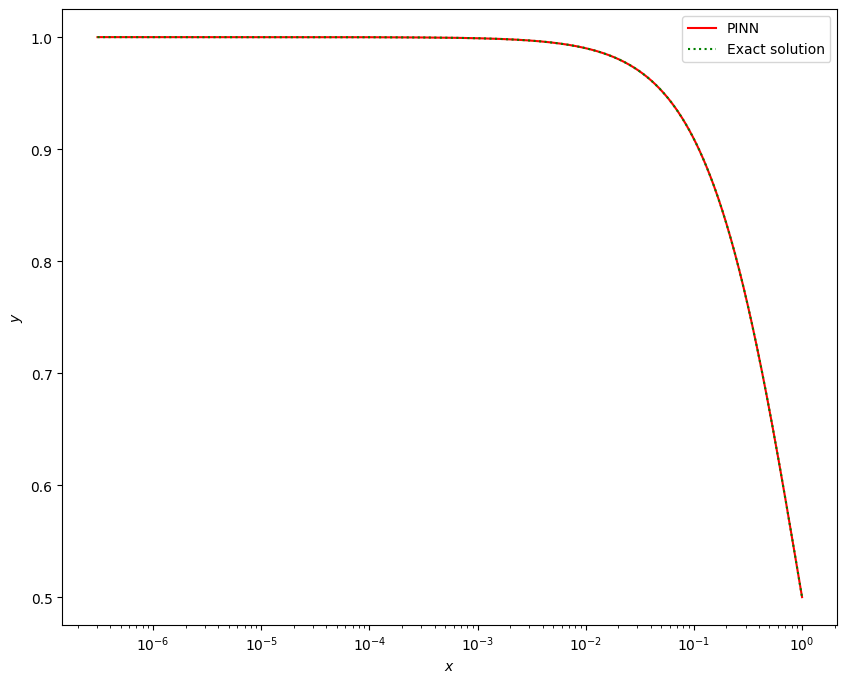

-----------------------------------------
Running for C = 1.6237767391887217
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.001749 | ODE: 0.000051 | IC: 1.001698
Epoch 10000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.

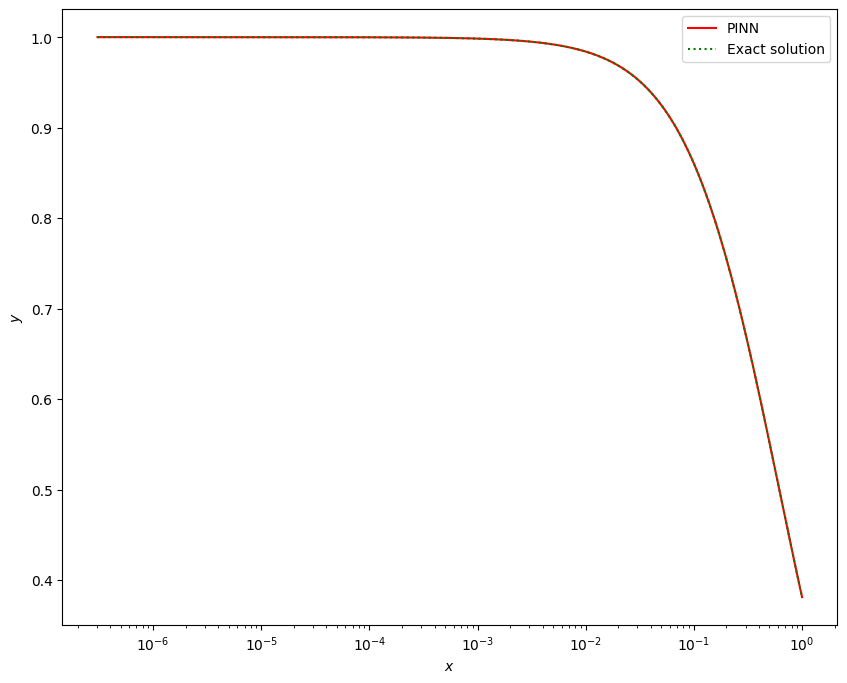

-----------------------------------------
Running for C = 2.636650898730358
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.295152 | ODE: 0.001739 | IC: 1.293413
Epoch 10000 | Best: 0.000005 | Total: 0.000005 | ODE: 0.000005 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

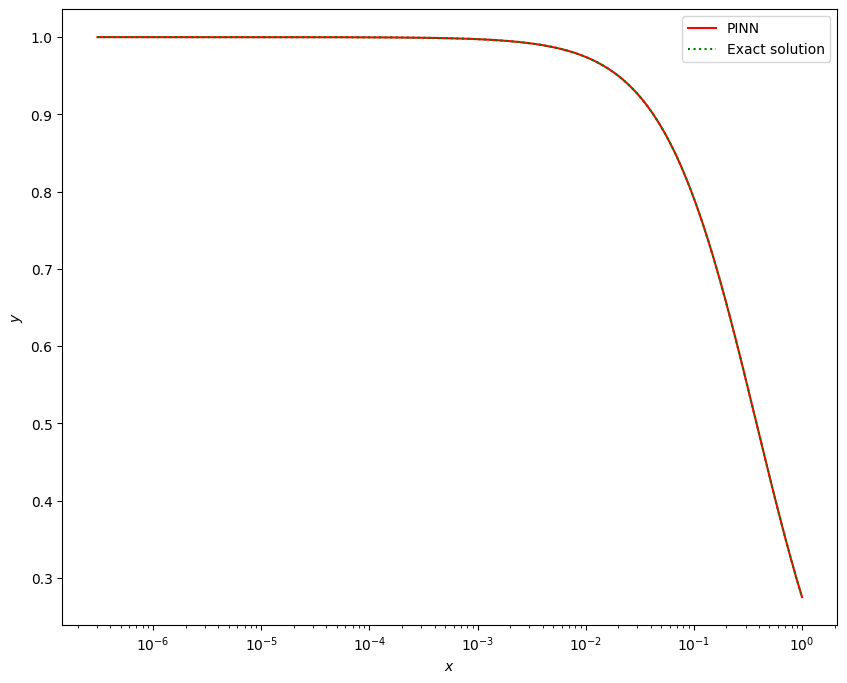

-----------------------------------------
Running for C = 4.281332398719393
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.970123 | ODE: 0.000007 | IC: 0.970117
Epoch 10000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


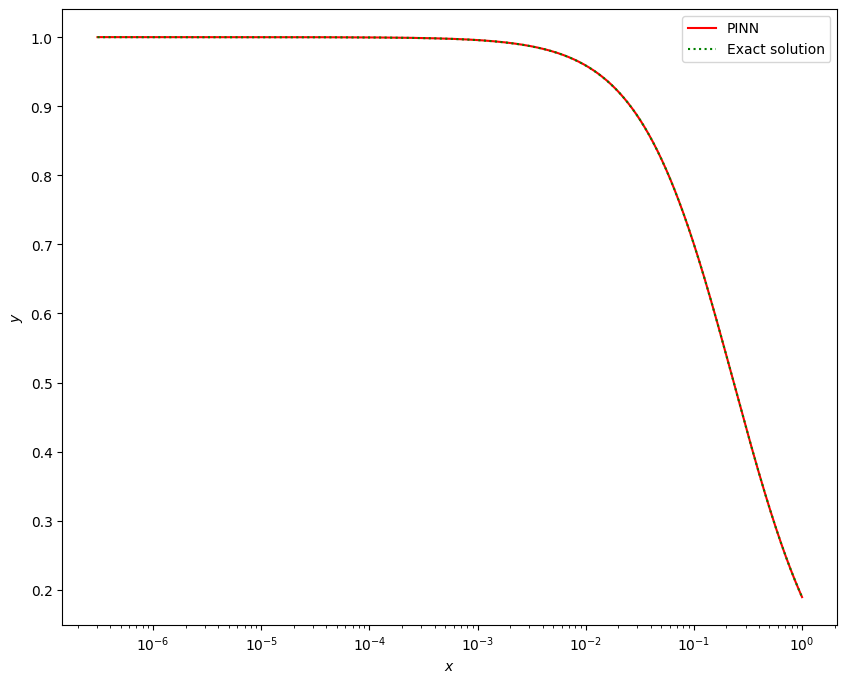

-----------------------------------------
Running for C = 6.951927961775605
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.888695 | ODE: 0.000158 | IC: 0.888537
Epoch 10000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


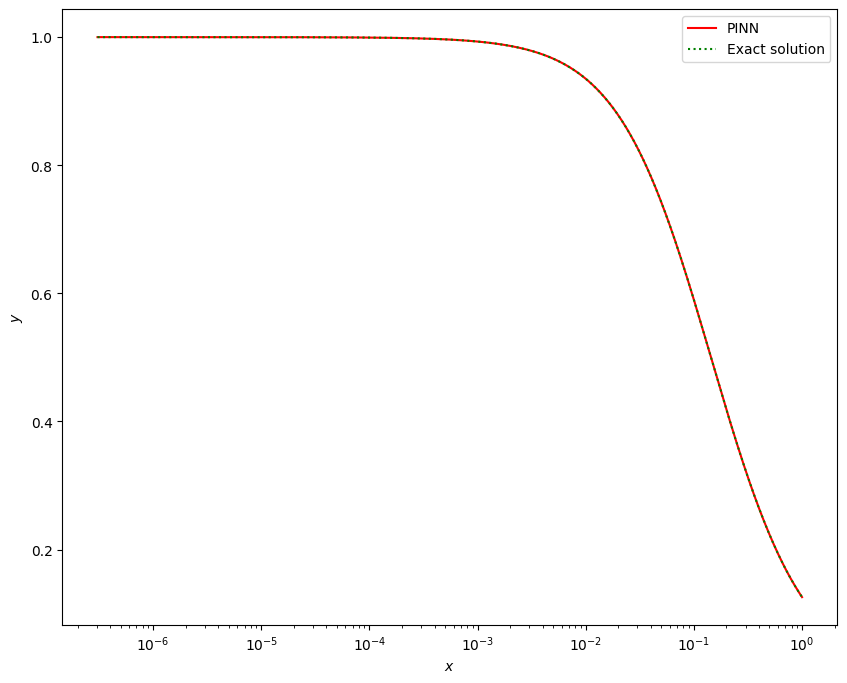

-----------------------------------------
Running for C = 11.28837891684689
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.089960 | ODE: 0.000468 | IC: 1.089491
Epoch 10000 | Best: 0.000005 | Total: 0.000005 | ODE: 0.000005 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


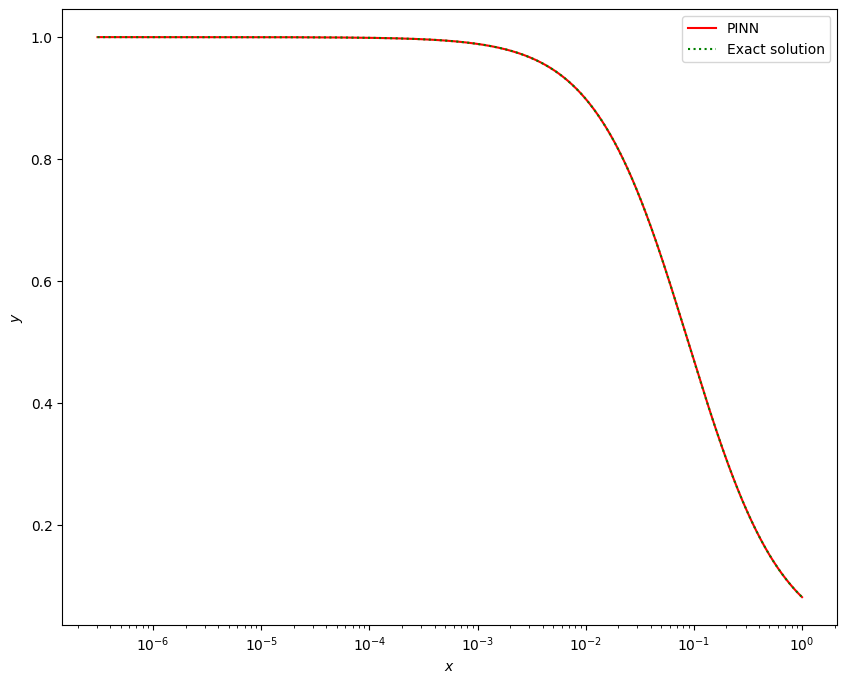

-----------------------------------------
Running for C = 18.329807108324356
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.727481 | ODE: 0.005392 | IC: 0.722089
Epoch 10000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


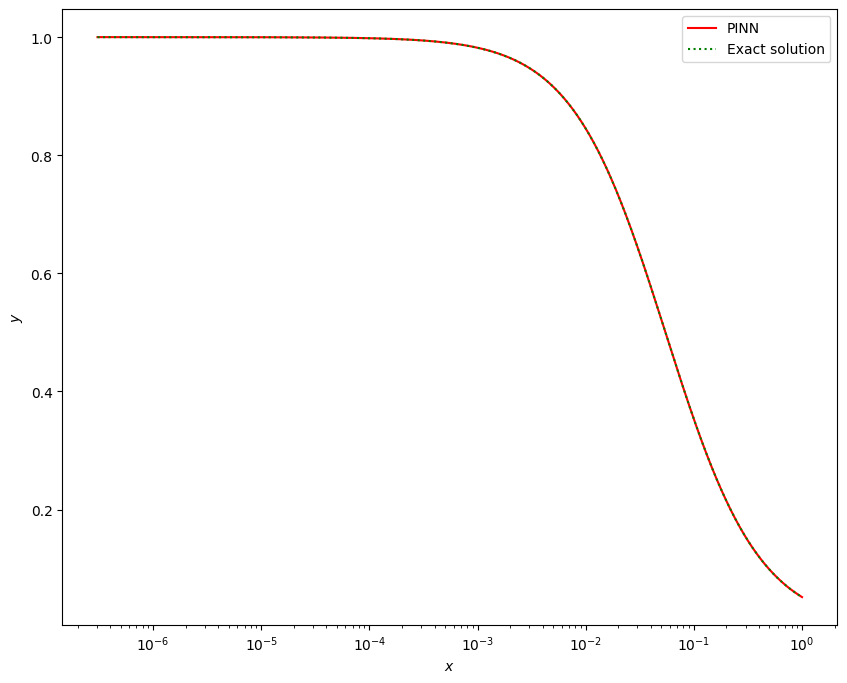

-----------------------------------------
Running for C = 29.763514416313175
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.687208 | ODE: 0.007589 | IC: 0.679618
Epoch 10000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.

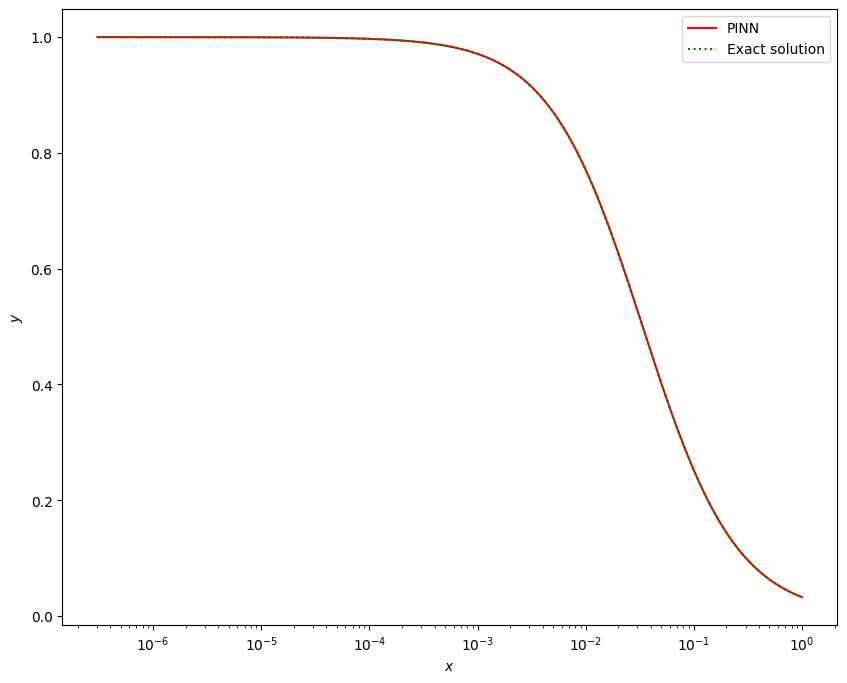

-----------------------------------------
Running for C = 48.32930238571752
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.188933 | ODE: 0.001973 | IC: 1.186959
Epoch 10000 | Best: 0.000020 | Total: 0.000021 | ODE: 0.000020 | IC: 0.000001
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000002 | ODE: 0.000000 | IC: 0.000001
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

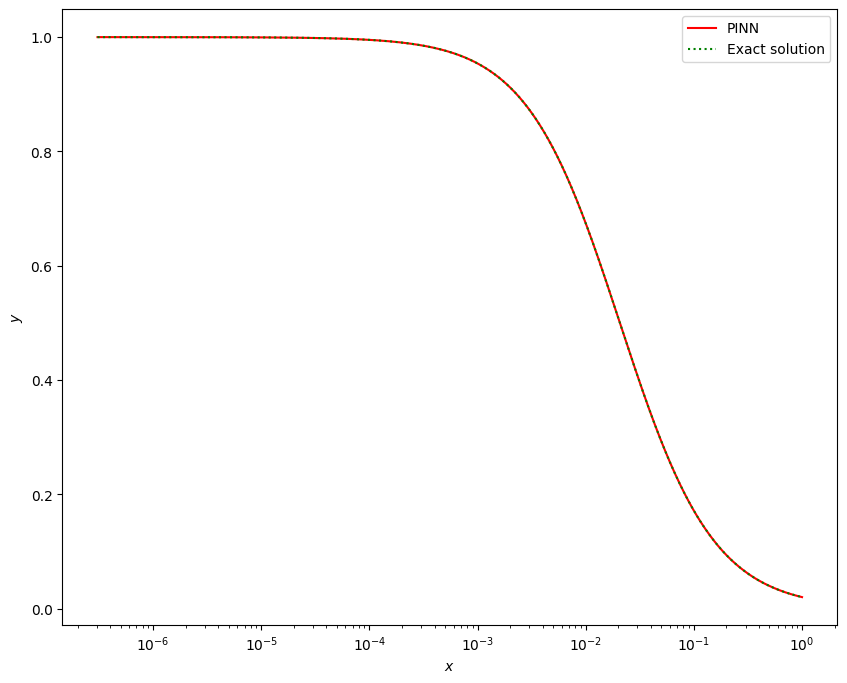

-----------------------------------------
Running for C = 78.47599703514611
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.891694 | ODE: 0.000823 | IC: 0.890872
Epoch 10000 | Best: 0.000019 | Total: 0.000019 | ODE: 0.000019 | IC: 0.000000
Epoch 20000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000009 | ODE: 0.000000 | IC: 0.000009
Epoch 80000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

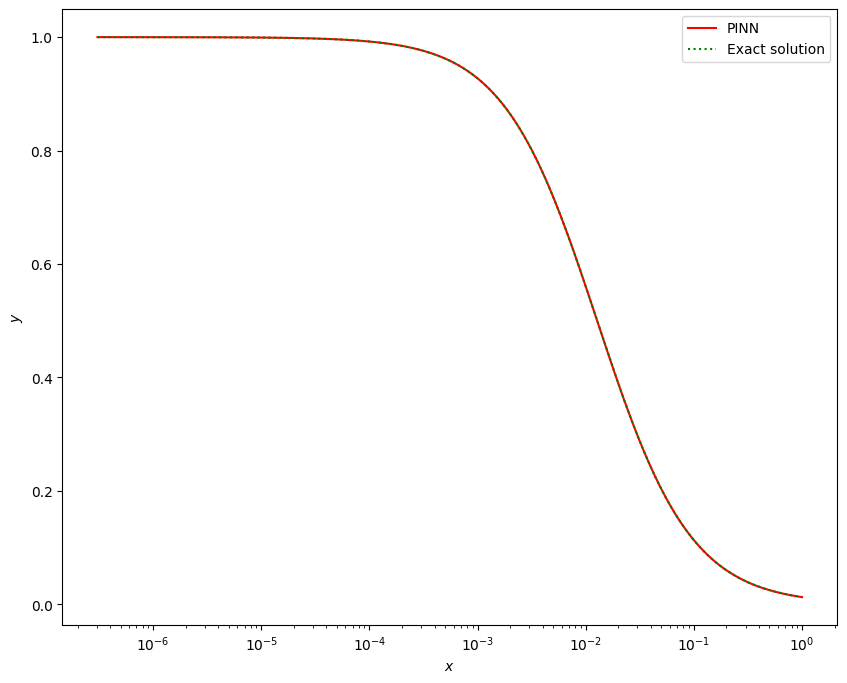

-----------------------------------------
Running for C = 127.42749857031335
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.847764 | ODE: 0.001622 | IC: 0.846142
Epoch 10000 | Best: 0.000041 | Total: 0.000041 | ODE: 0.000041 | IC: 0.000000
Epoch 20000 | Best: 0.000002 | Total: 0.000009 | ODE: 0.000002 | IC: 0.000007
Epoch 30000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000002 | ODE: 0.000000 | IC: 0.000002
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.

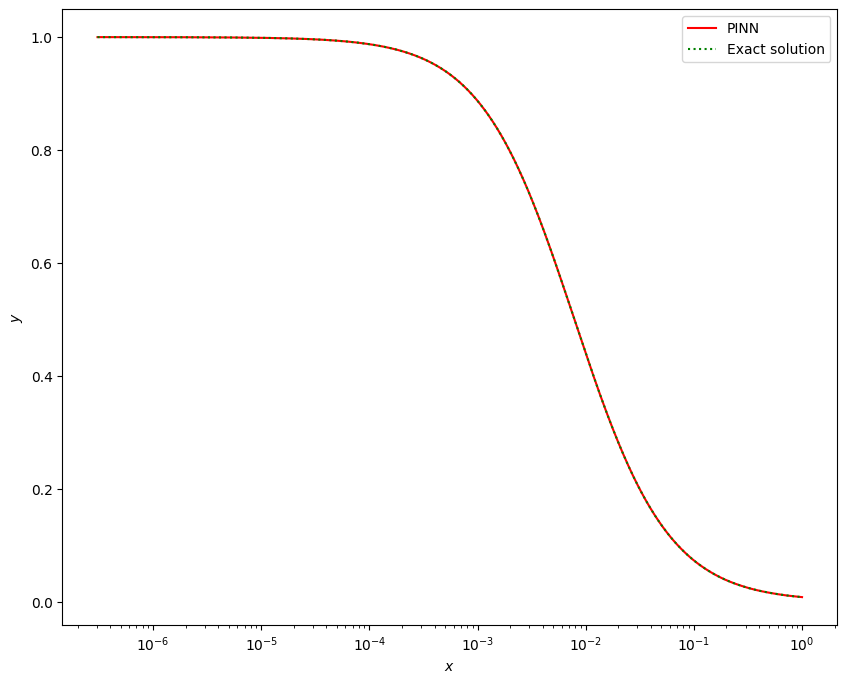

-----------------------------------------
Running for C = 206.913808111479
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.791807 | ODE: 0.003057 | IC: 0.788750
Epoch 10000 | Best: 0.000174 | Total: 0.000174 | ODE: 0.000173 | IC: 0.000001
Epoch 20000 | Best: 0.000007 | Total: 0.000037 | ODE: 0.000008 | IC: 0.000029
Epoch 30000 | Best: 0.000001 | Total: 0.000002 | ODE: 0.000001 | IC: 0.000000
Epoch 40000 | Best: 0.000001 | Total: 0.000006 | ODE: 0.000001 | IC: 0.000005
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.00

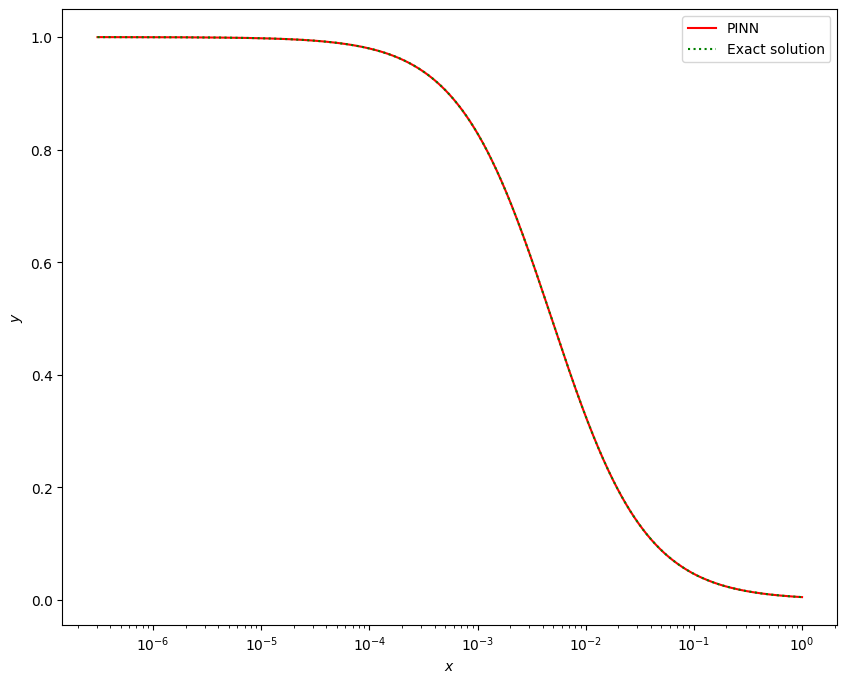

-----------------------------------------
Running for C = 335.9818286283781
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.202904 | ODE: 0.002294 | IC: 1.200610
Epoch 10000 | Best: 0.000799 | Total: 0.000798 | ODE: 0.000779 | IC: 0.000020
Epoch 20000 | Best: 0.000016 | Total: 0.000027 | ODE: 0.000016 | IC: 0.000011
Epoch 30000 | Best: 0.000003 | Total: 0.000007 | ODE: 0.000003 | IC: 0.000004
Epoch 40000 | Best: 0.000001 | Total: 0.000016 | ODE: 0.000002 | IC: 0.000014
Epoch 50000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 60000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

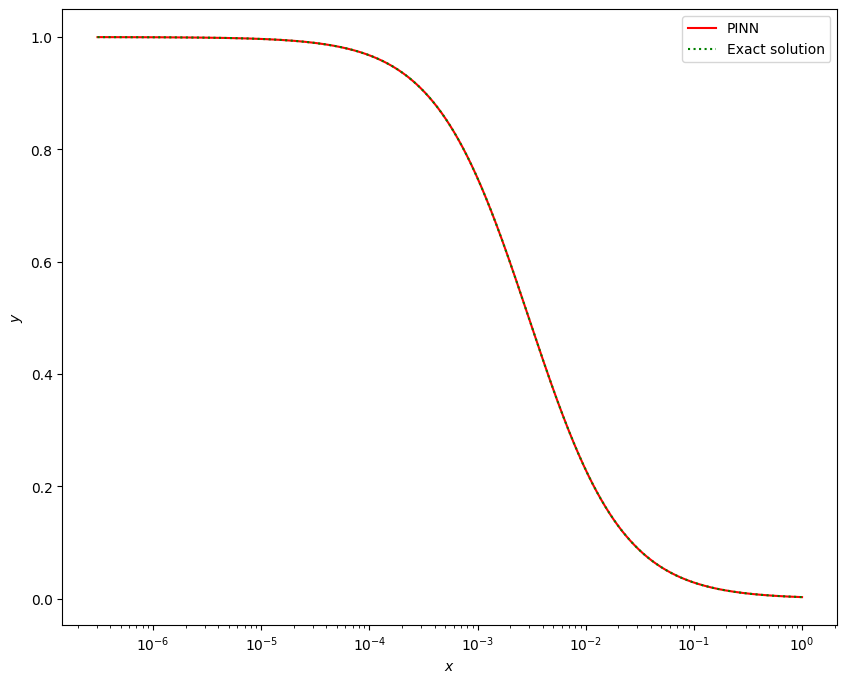

-----------------------------------------
Running for C = 545.5594781168514
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.782392 | ODE: 0.003441 | IC: 0.778951
Epoch 10000 | Best: 0.002790 | Total: 0.002791 | ODE: 0.002717 | IC: 0.000074
Epoch 20000 | Best: 0.000095 | Total: 0.000095 | ODE: 0.000094 | IC: 0.000000
Epoch 30000 | Best: 0.000015 | Total: 0.000015 | ODE: 0.000015 | IC: 0.000000
Epoch 40000 | Best: 0.000005 | Total: 0.000005 | ODE: 0.000005 | IC: 0.000000
Epoch 50000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 60000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 70000 | Best: 0.000001 | Total: 0.000005 | ODE: 0.000001 | IC: 0.000003
Epoch 80000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 90000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 100000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 110000 | Best: 0.0

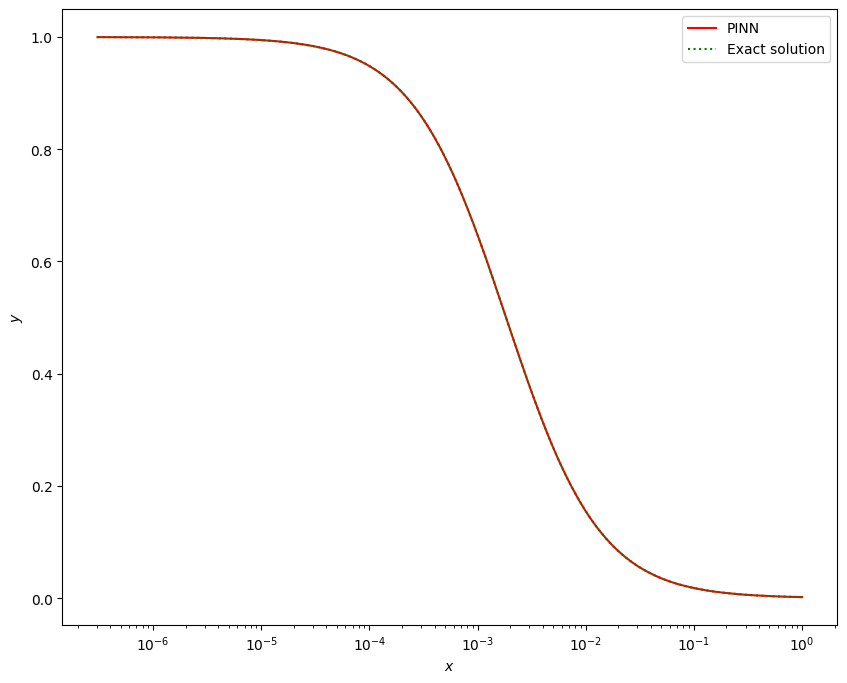

-----------------------------------------
Running for C = 885.8667904100823
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.070448 | ODE: 0.000302 | IC: 1.070146
Epoch 10000 | Best: 0.019927 | Total: 0.019918 | ODE: 0.017561 | IC: 0.002358
Epoch 20000 | Best: 0.000611 | Total: 0.000611 | ODE: 0.000598 | IC: 0.000013
Epoch 30000 | Best: 0.000051 | Total: 0.000051 | ODE: 0.000051 | IC: 0.000000
Epoch 40000 | Best: 0.000012 | Total: 0.000012 | ODE: 0.000012 | IC: 0.000000
Epoch 50000 | Best: 0.000005 | Total: 0.000035 | ODE: 0.000005 | IC: 0.000030
Epoch 60000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 70000 | Best: 0.000002 | Total: 0.000004 | ODE: 0.000002 | IC: 0.000001
Epoch 80000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 90000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 100000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 110000 | Best: 0.0

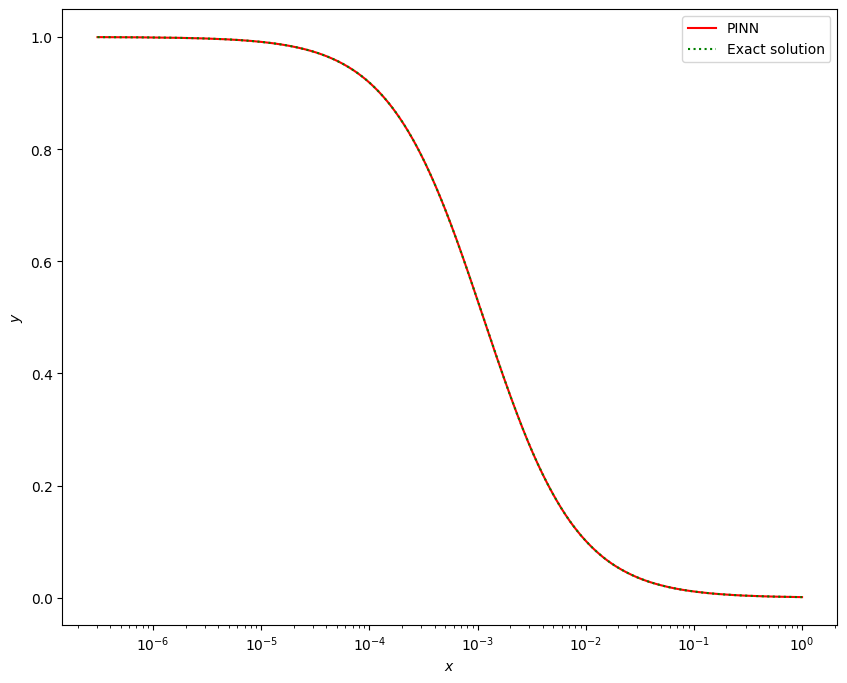

-----------------------------------------
Running for C = 1438.449888287663
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.017085 | ODE: 0.000020 | IC: 1.017065
Epoch 10000 | Best: 0.052758 | Total: 0.052763 | ODE: 0.046999 | IC: 0.005764
Epoch 20000 | Best: 0.005228 | Total: 0.005227 | ODE: 0.004898 | IC: 0.000329
Epoch 30000 | Best: 0.000751 | Total: 0.000751 | ODE: 0.000741 | IC: 0.000010
Epoch 40000 | Best: 0.000124 | Total: 0.000124 | ODE: 0.000123 | IC: 0.000000
Epoch 50000 | Best: 0.000043 | Total: 0.000045 | ODE: 0.000042 | IC: 0.000003
Epoch 60000 | Best: 0.000020 | Total: 0.000021 | ODE: 0.000020 | IC: 0.000000
Epoch 70000 | Best: 0.000012 | Total: 0.000027 | ODE: 0.000013 | IC: 0.000015
Epoch 80000 | Best: 0.000008 | Total: 0.000008 | ODE: 0.000008 | IC: 0.000000
Epoch 90000 | Best: 0.000006 | Total: 0.000006 | ODE: 0.000006 | IC: 0.000000
Epoch 100000 | Best: 0.000004 | Total: 0.000004 | ODE: 0.000004 | IC: 0.000000
Epoch 110000 | Best: 0.0

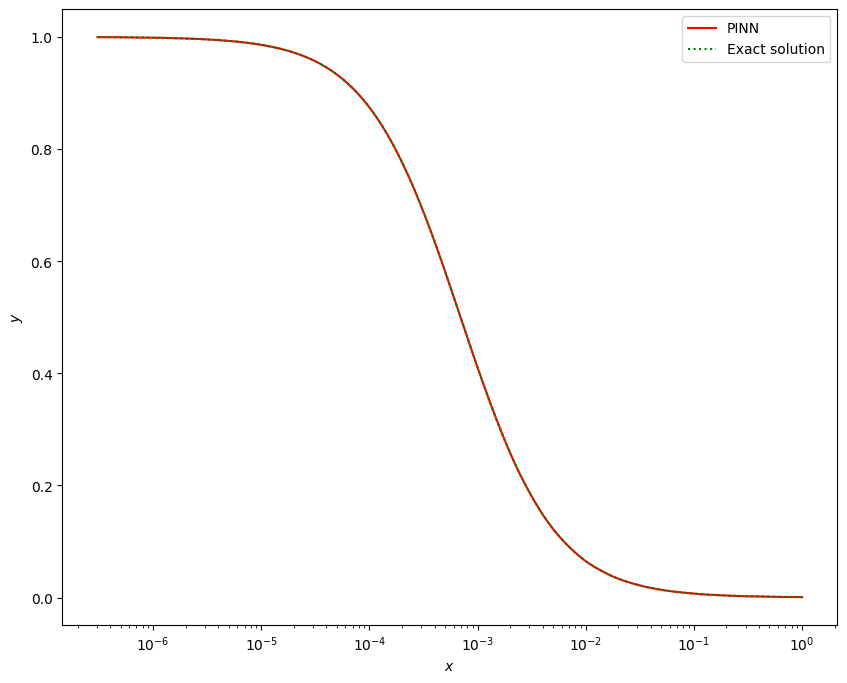

-----------------------------------------
Running for C = 2335.7214690901214
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.805691 | ODE: 0.002667 | IC: 0.803023
Epoch 10000 | Best: 0.120325 | Total: 0.120324 | ODE: 0.103435 | IC: 0.016889
Epoch 20000 | Best: 0.054460 | Total: 0.054453 | ODE: 0.047711 | IC: 0.006742
Epoch 30000 | Best: 0.011802 | Total: 0.011800 | ODE: 0.010836 | IC: 0.000965
Epoch 40000 | Best: 0.003251 | Total: 0.003250 | ODE: 0.003154 | IC: 0.000096
Epoch 50000 | Best: 0.001123 | Total: 0.001123 | ODE: 0.001111 | IC: 0.000012
Epoch 60000 | Best: 0.000207 | Total: 0.000207 | ODE: 0.000203 | IC: 0.000003
Epoch 70000 | Best: 0.000066 | Total: 0.000076 | ODE: 0.000069 | IC: 0.000008
Epoch 80000 | Best: 0.000033 | Total: 0.000034 | ODE: 0.000033 | IC: 0.000001
Epoch 90000 | Best: 0.000020 | Total: 0.000021 | ODE: 0.000021 | IC: 0.000000
Epoch 100000 | Best: 0.000014 | Total: 0.000014 | ODE: 0.000014 | IC: 0.000000
Epoch 110000 | Best: 0.

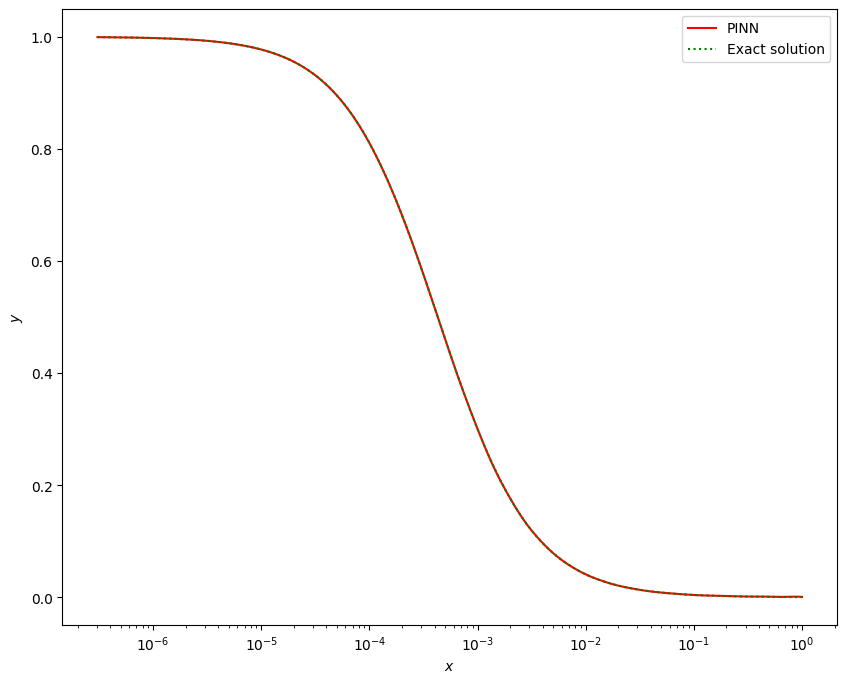

-----------------------------------------
Running for C = 3792.690190732246
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.399559 | ODE: 0.008166 | IC: 1.391393
Epoch 10000 | Best: 0.158733 | Total: 0.158732 | ODE: 0.133125 | IC: 0.025607
Epoch 20000 | Best: 0.109806 | Total: 0.109797 | ODE: 0.095339 | IC: 0.014458
Epoch 30000 | Best: 0.052497 | Total: 0.052476 | ODE: 0.046431 | IC: 0.006045
Epoch 40000 | Best: 0.023573 | Total: 0.023572 | ODE: 0.021286 | IC: 0.002285
Epoch 50000 | Best: 0.010499 | Total: 0.010498 | ODE: 0.009767 | IC: 0.000730
Epoch 60000 | Best: 0.004836 | Total: 0.004835 | ODE: 0.004623 | IC: 0.000213
Epoch 70000 | Best: 0.002169 | Total: 0.002206 | ODE: 0.002203 | IC: 0.000003
Epoch 80000 | Best: 0.001031 | Total: 0.001033 | ODE: 0.001026 | IC: 0.000007
Epoch 90000 | Best: 0.000946 | Total: 0.015850 | ODE: 0.014406 | IC: 0.001443
Epoch 100000 | Best: 0.000946 | Total: 0.007200 | ODE: 0.006754 | IC: 0.000445
Epoch 110000 | Best: 0.0

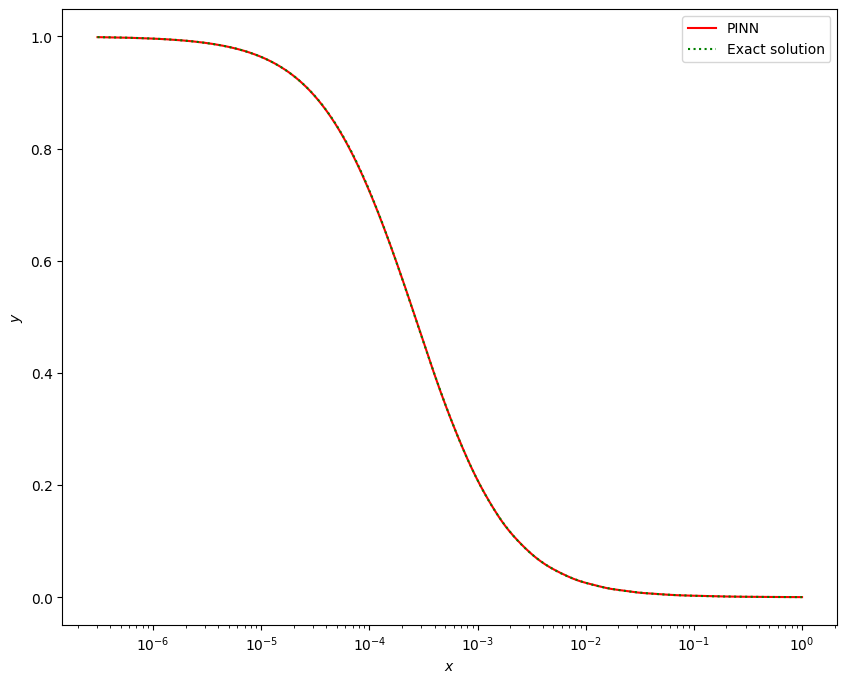

-----------------------------------------
Running for C = 6158.48211066026
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.775284 | ODE: 0.003596 | IC: 0.771689
Epoch 10000 | Best: 0.128931 | Total: 0.129319 | ODE: 0.111270 | IC: 0.018049
Epoch 20000 | Best: 0.117647 | Total: 0.117641 | ODE: 0.102118 | IC: 0.015523
Epoch 30000 | Best: 0.058540 | Total: 0.058482 | ODE: 0.051500 | IC: 0.006982
Epoch 40000 | Best: 0.037090 | Total: 0.037374 | ODE: 0.033779 | IC: 0.003595
Epoch 50000 | Best: 0.026221 | Total: 0.097890 | ODE: 0.083766 | IC: 0.014124
Epoch 60000 | Best: 0.026221 | Total: 0.069409 | ODE: 0.061038 | IC: 0.008371
Epoch 70000 | Best: 0.016239 | Total: 0.016239 | ODE: 0.015022 | IC: 0.001217
Epoch 80000 | Best: 0.007224 | Total: 0.007223 | ODE: 0.006850 | IC: 0.000373
Epoch 90000 | Best: 0.004297 | Total: 0.004629 | ODE: 0.004466 | IC: 0.000163
Epoch 100000 | Best: 0.003528 | Total: 0.003539 | ODE: 0.003337 | IC: 0.000202
Epoch 110000 | Best: 0.00

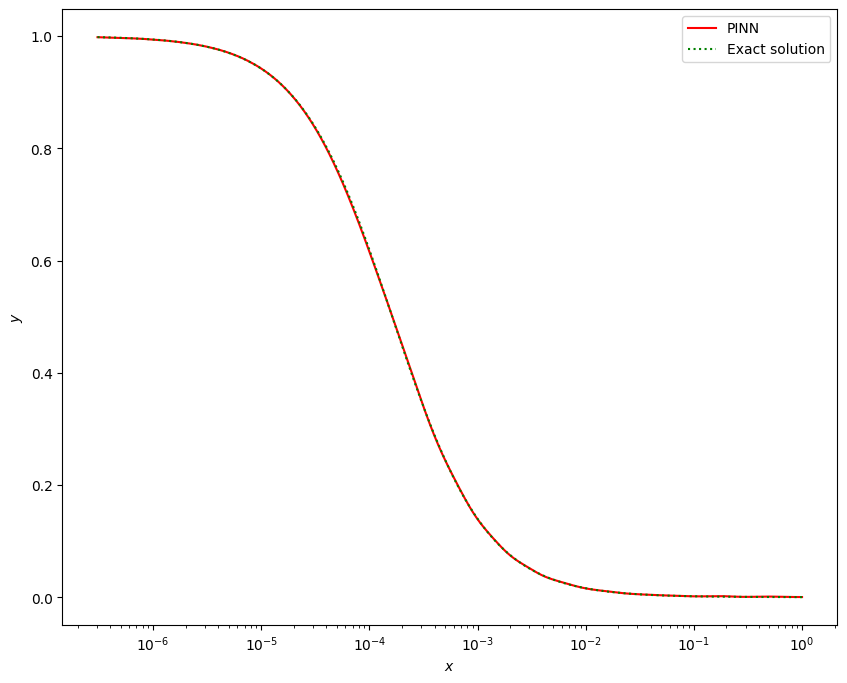

-----------------------------------------
Running for C = 10000.0
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.853293 | ODE: 0.001363 | IC: 0.851929
Epoch 10000 | Best: 0.122566 | Total: 0.122559 | ODE: 0.106058 | IC: 0.016501
Epoch 20000 | Best: 0.113137 | Total: 0.113170 | ODE: 0.098571 | IC: 0.014599
Epoch 30000 | Best: 0.107076 | Total: 0.107074 | ODE: 0.093631 | IC: 0.013443
Epoch 40000 | Best: 0.082812 | Total: 0.082809 | ODE: 0.073258 | IC: 0.009551
Epoch 50000 | Best: 0.054618 | Total: 0.054687 | ODE: 0.047580 | IC: 0.007108
Epoch 60000 | Best: 0.035685 | Total: 0.035684 | ODE: 0.032485 | IC: 0.003199
Epoch 70000 | Best: 0.030764 | Total: 0.030765 | ODE: 0.028010 | IC: 0.002754
Epoch 80000 | Best: 0.022302 | Total: 0.022300 | ODE: 0.020691 | IC: 0.001609
Epoch 90000 | Best: 0.016411 | Total: 0.016411 | ODE: 0.015264 | IC: 0.001147
Epoch 100000 | Best: 0.011444 | Total: 0.011809 | ODE: 0.011735 | IC: 0.000074
Epoch 110000 | Best: 0.007512 | To

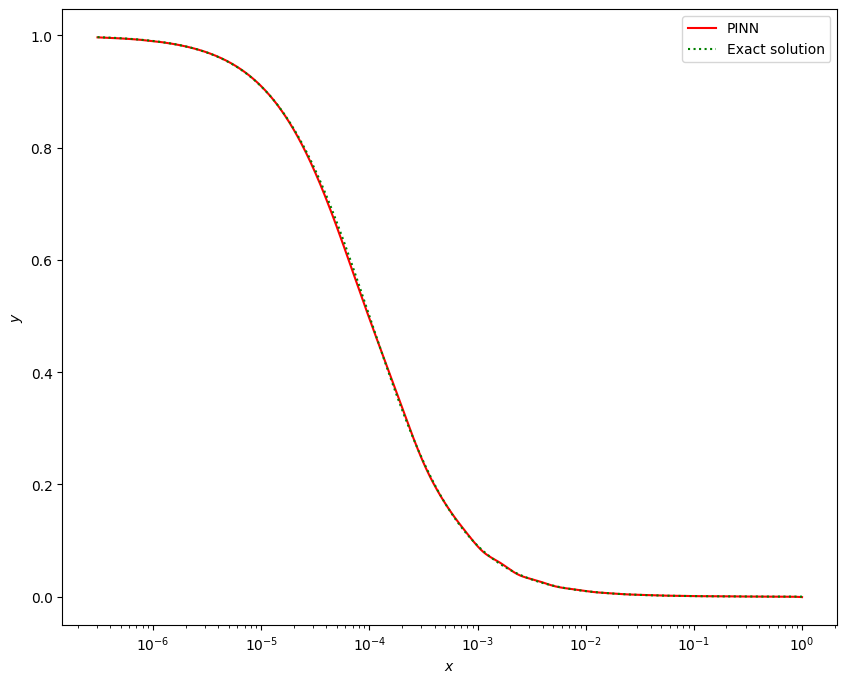

In [7]:
lst_eig_max = experiment(C_test, n_epochs)

In [8]:
# Print list of maximum hessian eigenvalues
print("Eigenvalue list:")
print([round(x, 2) for x in lst_eig_max])

Eigenvalue list:
[5.98, 7.19, 9.78, 11.49, 12.12, 20.12, 15.35, 20.42, 40.43, 63.6, 23.87, 61.22, 224.58, 286.62, 112.39, 470.08, 434.07, 1622.87, 1899.34, 10566.02]
